# Kalshi series: volume and frequency groups

First build each table and chart on the full universe. Then change the selection parameters and rerun the same cells for the selected subset.

### Load raw series
Read series metadata from SQLite; the data is not modified.

In [1]:
from pathlib import Path
import sqlite3

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 80)

db_candidates = [
    Path("../db/kalshi_daily_probability_dataset.sqlite"),
    Path("db/kalshi_daily_probability_dataset.sqlite"),
]
DB_PATH = next((path for path in db_candidates if path.exists()), None)

query = """
SELECT series_ticker, source, title, subtitle, category, tags_json,
       frequency, status, created_time, updated_time, close_time,
       settlement_time, volume_fp
FROM raw_series
"""
with sqlite3.connect(DB_PATH) as connection:
    series = pd.read_sql_query(query, connection)

series["frequency"] = series["frequency"].fillna("missing").astype(str)
series["category"] = series["category"].fillna("missing").astype(str)
series["volume_fp"] = pd.to_numeric(series["volume_fp"], errors="coerce").fillna(0)
print(f"Database: {DB_PATH.resolve()}")
print(f"Loaded {len(series):,} series")

Database: /Users/sneddy/research/pred_markets_clean/daily_export/db/kalshi_daily_probability_dataset.sqlite
Loaded 13,029 series


### Shared functions and groups
Provides reusable selection criteria, tables, and individual visualizations.

In [2]:
import sys
from pathlib import Path

package_root = next(
    (candidate for candidate in [Path.cwd(), *Path.cwd().parents]
     if (candidate / "kalshi_daily_research").is_dir()),
    None,
)
if package_root is None:
    raise FileNotFoundError("Could not find the kalshi_daily_research package")
if str(package_root) not in sys.path:
    sys.path.insert(0, str(package_root))

from kalshi_daily_research.series_selection import (
    GROUP_COLORS,
    GROUP_ORDER,
    LONG_RECC,
    SHORT_RECC,
    add_frequency_group,
    select_series,
)
from kalshi_daily_research.series_diagnostics import (
    category_table,
    frequency_table,
    group_table,
    plot_category_counts,
    plot_frequency_counts,
    plot_group_counts,
    plot_group_volume,
    plot_log_volume,
    plot_threshold_counts,
    selection_summary,
    threshold_table,
    top_volume_table,
    volume_bucket_table,
)

series = add_frequency_group(series)

## 1. Volume: baseline across all series

In [4]:
BASELINE_MIN_VOLUME = 0
active_series = select_series(series, min_volume=BASELINE_MIN_VOLUME)
print(f"Active series: {len(active_series):,}")

Active series: 13,029


### Summary baseline
Shows the universe size and basic volume statistics.

In [5]:
display(selection_summary(active_series).style.format("{:,.0f}"))

,value
series_count,"13,029"
volume_zero,"3,224"
volume_positive,"9,805"
volume_total,"136,650,968,121"
volume_median,"17,983"
volume_p90,"1,580,923"
volume_max,"11,792,733,527"


### Sensitivity to the volume threshold
Shows how many series and what share of volume remain at different thresholds.

In [6]:
display(threshold_table(active_series).style.format({"share_of_series_pct": "{:.1f}%", "share_of_volume_pct": "{:.1f}%"}))

,min_volume,series_count,share_of_series_pct,share_of_volume_pct
0,0,13029,100.0%,100.0%
1,100,9658,74.1%,100.0%
2,1000,9194,70.6%,100.0%
3,10000,7351,56.4%,100.0%
4,100000,3995,30.7%,99.9%
5,1000000,1594,12.2%,99.3%


### Threshold curve
Shows how the number of series changes as min_volume increases.

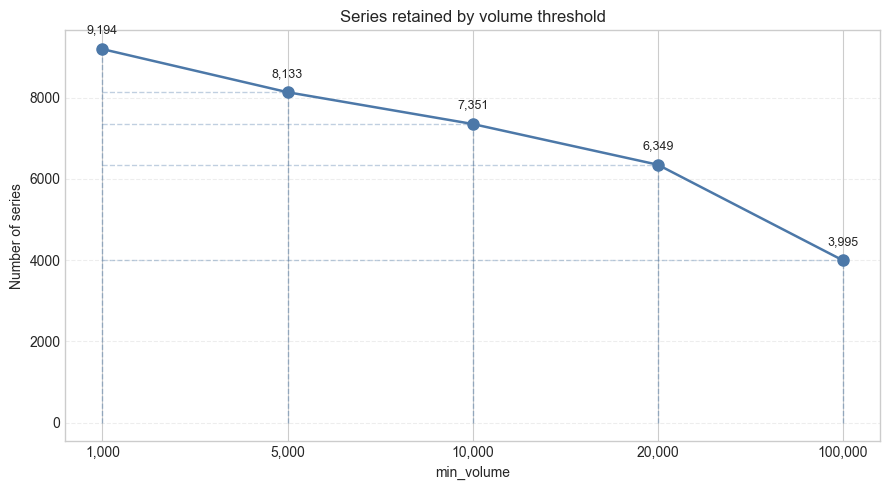

In [7]:
_ = plot_threshold_counts(active_series, thresholds=(1_000, 5_000, 10_000, 20_000, 100_000))

### Initial volume floor
Keeps only series with an aggregated volume of at least $10,000.

In [8]:
MIN_VOLUME = 10_000
active_series = select_series(series, min_volume=MIN_VOLUME)
print(f"Active series after {MIN_VOLUME:,.0f} volume floor: {len(active_series):,}")

Active series after 10,000 volume floor: 7,351


### Frequency table
Shows the raw frequency values and the number of series in each.

In [9]:
display(frequency_table(active_series))

,series_count
frequency,
custom,3160
one_off,2912
annual,862
monthly,179
weekly,106
daily,93
hourly,27
fifteen_min,12


### Frequency distribution
Shows the distribution of series by raw frequency.

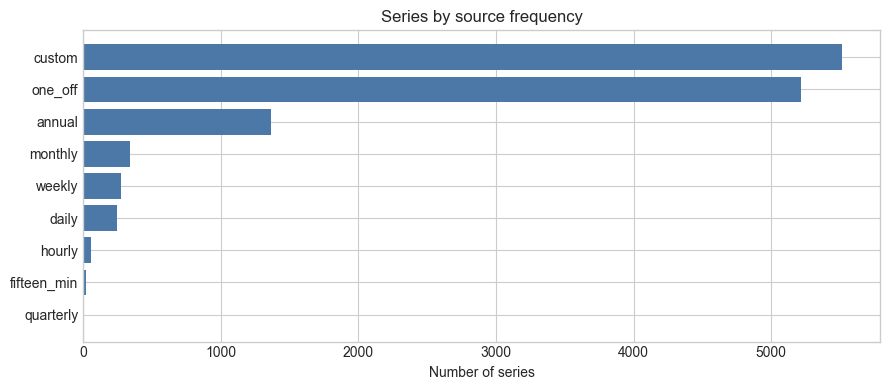

In [32]:
_ = plot_frequency_counts(active_series)

### Operational group table
Shows short_recc, long_recc, and rest as counts and percentages.

In [33]:
display(group_table(active_series).style.format({"share_pct": "{:.1f}%"}))

,series_count,share_pct
frequency_group,,
short_recc,594,4.6%
long_recc,1706,13.1%
rest,10729,82.3%


### Operational group distribution
Visually compares the three operational frequency groups.

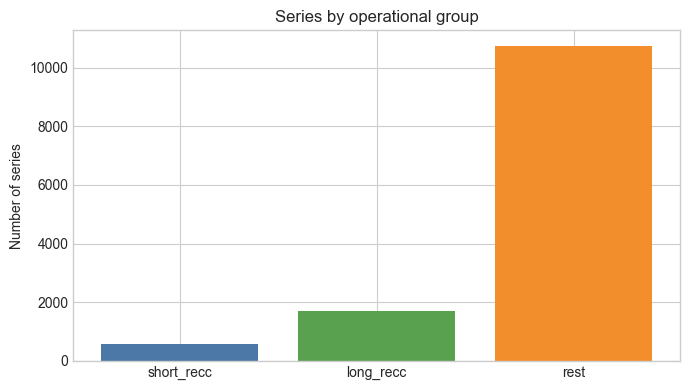

In [34]:
_ = plot_group_counts(active_series)

### Category table
Shows the most represented categories in the current universe.

In [36]:
display(category_table(active_series, top_n=20))

,series_count
category,
Sports,3403
Entertainment,2500
Politics,2150
Elections,1558
Financials,891
Economics,622
Mentions,407
Climate and Weather,336
Science and Technology,299


### Category distribution
Shows the distribution of the top categories.

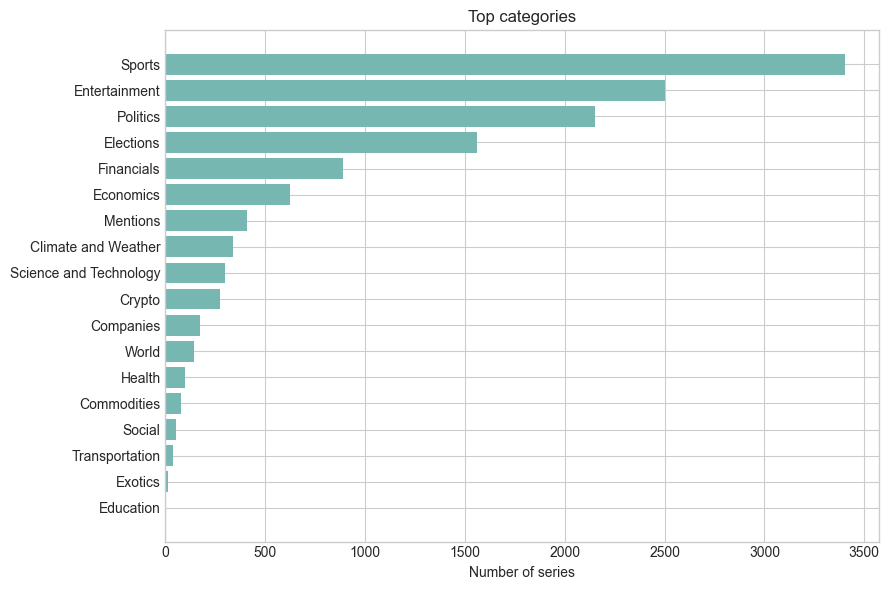

In [37]:
_ = plot_category_counts(active_series, top_n=20)

### Top-volume series
Shows the individual series with the highest aggregated volume.

In [38]:
display(top_volume_table(active_series, top_n=25).style.format({"volume_fp": "{:,.0f}"}))

,series_ticker,title,category,frequency,frequency_group,volume_fp
4633,KXBTC15M,Bitcoin price up down,Crypto,fifteen_min,short_recc,"11,792,733,527"
11943,KXNBAGAME,Pro Basketball Game,Sports,custom,rest,"11,675,949,307"
7001,KXMLBGAME,Professional Baseball Game,Sports,custom,rest,"8,307,812,672"
2472,KXBTCD,Bitcoin price Above/below,Crypto,hourly,short_recc,"6,224,341,657"
11749,KXNCAAMBGAME,Men's College Basketball Men's Game,Sports,custom,rest,"5,936,932,933"
6217,KXATPMATCH,ATP Tennis Match,Sports,custom,rest,"5,458,739,537"
7043,KXNFLGAME,Professional Football Game,Sports,custom,rest,"5,342,391,368"
8961,KXATPCHALLENGERMATCH,Challenger ATP,Sports,custom,rest,"4,588,071,827"
8411,KXWCGAME,World Cup Game,Sports,custom,rest,"4,494,733,439"
11081,KXNCAAFGAME,College Football Game,Sports,custom,rest,"4,021,648,345"


### Top-volume series with category exclusions
Shows the top-volume series after optionally excluding selected raw categories.

In [ ]:
TOP_VOLUME_EXCLUDE_CATEGORIES = ("Sports",)
top_volume_universe = select_series(
    active_series,
    exclude_categories=TOP_VOLUME_EXCLUDE_CATEGORIES,
)
display(top_volume_table(top_volume_universe, top_n=100).style.format({"volume_fp": "{:,.0f}"}))

## 2. Rerun after selecting criteria

Change only this cell, then rerun the visualization cells above. The main parameter is `MIN_VOLUME`; the other exclusions are optional.

### Filtered universe
Applies min_volume and excludes unwanted frequency groups, categories, or frequencies.

In [39]:
MIN_VOLUME = 10_000
EXCLUDE_GROUPS = "short_recc"  # e.g. ["short_recc"]
EXCLUDE_CATEGORIES = None  # e.g. ["Sports", "Politics"]
EXCLUDE_FREQUENCIES = None  # e.g. ["daily", "weekly"]

active_series = select_series(
    series,
    min_volume=MIN_VOLUME,
    exclude_groups=EXCLUDE_GROUPS,
    exclude_categories=EXCLUDE_CATEGORIES,
    exclude_frequencies=EXCLUDE_FREQUENCIES,
)
print(f"Active series: {len(active_series):,}")

Active series: 7,113


After changing the parameters, the same cells above use the new `active_series`; there is no separate logic for the filtered universe. `short_recc` can be excluded immediately, `long_recc` can remain optional, and `rest` can be analyzed separately.